In [59]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/nhtsa_vehicle_safety_recall_intelligence_ultimate.csv")
df = df.loc[df["recall_year"] <= 2025]  # on ignore toutes les données de 2026 car ça fausse les graphes
df.describe()

,nhtsa_record_id,vehicle_year,vehicle_year_num,recall_initiation_date,owner_notification_date,manufacture_date_begin,manufacture_date_end,recall_year,recall_month,recall_quarter,recall_age_days,days_to_owner_notification,potential_units_affected,units_affected_num,fire_risk_flag,manufacturer_recall_count,is_repeat_manufacturer,recall_risk_score,record_creation_date,defect_severity_score
count,46679.000000,45691.000000,45691.000000,4.667900e+04,4.613300e+04,2.303400e+04,2.292700e+04,46679.000000,46679.000000,46679.000000,46679.000000,46121.000000,4.667900e+04,4.667900e+04,46679.000000,46679.000000,46679.000000,46679.000000,4.667900e+04,46679.000000
mean,163942.747660,2014.504541,2014.504541,2.018354e+07,2.018332e+07,2.009968e+07,2.014327e+07,2018.286103,6.650549,2.549926,2741.237559,75.738622,2.573994e+05,2.573994e+05,0.003878,4107.911630,0.994344,34.085820,2.018353e+07,0.239624
std,67772.216133,6.340730,6.340730,4.419780e+04,1.528852e+05,1.639692e+05,9.207264e+04,4.420611,3.600913,1.166937,1615.414382,99.724412,6.690124e+05,6.690124e+05,0.062150,7801.750406,0.074992,14.009767,4.421210e+04,0.054689
min,81715.000000,1988.000000,1988.000000,2.010010e+07,1.111111e+07,2.090211e+06,1.900010e+07,2010.000000,1.000000,1.000000,118.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000,4.000000,2.010010e+07,0.053800
25%,111532.000000,2010.000000,2010.000000,2.015053e+07,2.015072e+07,2.006032e+07,2.011043e+07,2015.000000,3.000000,1.000000,1428.000000,29.000000,1.150000e+03,1.150000e+03,0.000000,479.000000,1.000000,21.000000,2.015053e+07,0.201900
50%,139802.000000,2015.000000,2015.000000,2.019011e+07,2.019030e+07,2.010053e+07,2.014120e+07,2019.000000,7.000000,3.000000,2659.000000,50.000000,1.560400e+04,1.560400e+04,0.000000,1614.000000,1.000000,32.000000,2.019013e+07,0.234300
75%,214985.000000,2020.000000,2020.000000,2.022052e+07,2.022071e+07,2.014052e+07,2.017110e+07,2022.000000,10.000000,4.000000,3983.000000,69.000000,1.746360e+05,1.746360e+05,0.000000,4177.000000,1.000000,43.000000,2.022052e+07,0.272200
max,316941.000000,2027.000000,2027.000000,2.025122e+07,2.026042e+07,3.019051e+07,3.016063e+07,2025.000000,12.000000,4.000000,5951.000000,2675.000000,1.760000e+07,1.760000e+07,1.000000,44051.000000,1.000000,69.000000,2.025123e+07,0.523300


In [61]:
df_mv_rates = pd.read_csv("../data/deaths-and-mv-rates-1913.csv")
df_mv_rates.describe()

,Category,Number of deaths,"Rate per 100,000,000 vehicle miles","Rate Per 10,000 motor vehicles"
count,111.000000,111.000000,101.000000,111.000000
mean,1968.000000,37665.720721,6.036040,6.622613
std,32.186954,11991.983926,5.313897,5.962209
min,1913.000000,4200.000000,1.170000,1.360000
25%,1940.500000,32798.500000,1.650000,2.090000
50%,1968.000000,39463.000000,4.240000,5.120000
75%,1995.500000,45579.500000,8.110000,10.490000
max,2023.000000,56278.000000,21.650000,33.380000


# Story
When Daniel was a young adult, he has a big car enthusiast. Unfortunately, he had an accident with his first car, because he braked all the way in his non-ABS car and couldn't steer. The accident left him a bit traumatized for the rest of his life.

Many years later without driving or getting any news from new cars, he saw that there was a Car Show in San Fransisco and decided to go to try to revive his old love for cars.

When he arrived at the airport, he had to go to the car show. He doesn't drive, so he must take a taxi to go there. No taxis are available, so Daniel looks at a car he had never seen before called Waymo. There was no driver in the car so he waited for a bit next to it until someone told him it's an autonomous car and he just has to get inside. Daniel was dumbfounded, "what the hell is this hillbilly talking about?" he said.

After a few minutes of convincing himself, he got in. The shock was huge, as he got in the car, it turned on and started asking questions.

When the trip ended near the car show, Daniel was still recovering from what he had just seen. He kept asking himself if that thing was safe.

During the whole show, Daniel seemed lost in his thoughts. Someone came up to him and asked what was wrong. Daniel explained how he had an accident earlier in his life and didn't get any car news since. Then he saw a Waymo and was shocked. The man introduced himself as Jack, a Silicon Valley engineer, who is a car and tech enthusiast.

Jack explained to Daniel how all cars nowadays have many safety features that older ones didn't have. For example, the accident Daniel had wouldn't have happened with a modern car, because they have ABS, which prevents the wheels from locking up. Jack also showed a poster in the wall showing how cars are becoming safer than before :

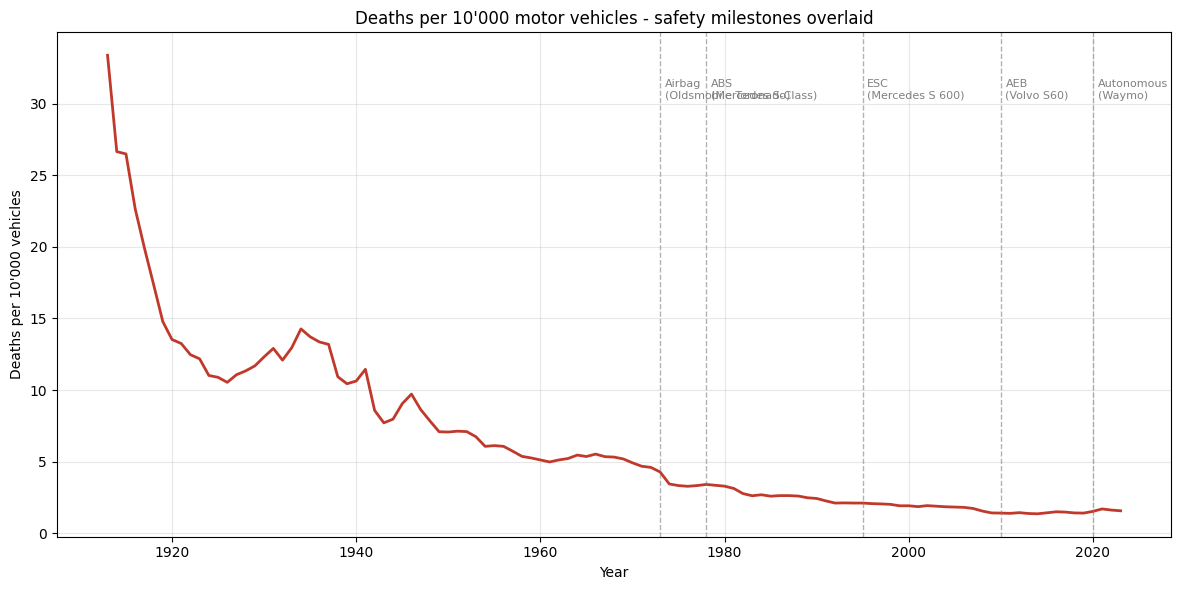

In [67]:
milestones = [
    (1973, "Airbag\n(Oldsmobile Toronado)"),
    (1978, "ABS\n(Mercedes S-Class)"),
    (1995, "ESC\n(Mercedes S 600)"),
    (2010, "AEB\n(Volvo S60)"),
    (2020, "Autonomous\n(Waymo)"),
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_mv_rates["Category"], df_mv_rates["Rate Per 10,000 motor vehicles"],
        color="#c0392b", linewidth=2)

ymax = df_mv_rates["Rate Per 10,000 motor vehicles"].max()
for year, label in milestones:
    ax.axvline(year, color="gray", linestyle="--", alpha=0.6, linewidth=1)
    ax.annotate(label, xy=(year, ymax * 0.95), xytext=(year + 0.5, ymax * 0.95),
                fontsize=8, color="gray", va="top")

ax.set_title("Deaths per 10'000 motor vehicles - safety milestones overlaid")
ax.set_xlabel("Year")
ax.set_ylabel("Deaths per 10'000 vehicles")
ax.grid(True, alpha=0.3)
plt.tight_layout()

Jake started walking and explaining cars to Daniel.
"Here you can see the 1978 Mercedes-Benz S-Class, the first car to feature ABS (Anti-Lock Braking System). This reduces mortality by 6% in cars and ~30% in motorcycles !" said Jack. He kept going.

"This is the 1973 Oldsmobile Toronado, the first comercially available car to feature airbags."

"Now, we have the 1995 Mercedes-Benz S 600 Coupé which was the first to feature the ESC system"

"Then, the first car that braked automatically was the 2010 Volvo S60."

"And finally, the car you came in from the airport, the Waymo. Autonomous taxi. If you look to your left, there is a Waymo poster explianing their security report. This shows that a Waymo is ~80-90% safer than the average driver."

![Waymo Security Report](../data/waymo_stats.png)

Daniel remained skeptical. "OK Jack, that's all nice on paper. But I read on billboards on the way here: *Tesla recalls 2 million vehicles*, *Toyota recalls 1 million for airbag defect*... If modern cars are so safe, why are there so many recalls?"

Jack smiled. "Good question. As it happens, the NHTSA - the US road safety agency - publishes every recall going back years. I have the data right here on my laptop, look."

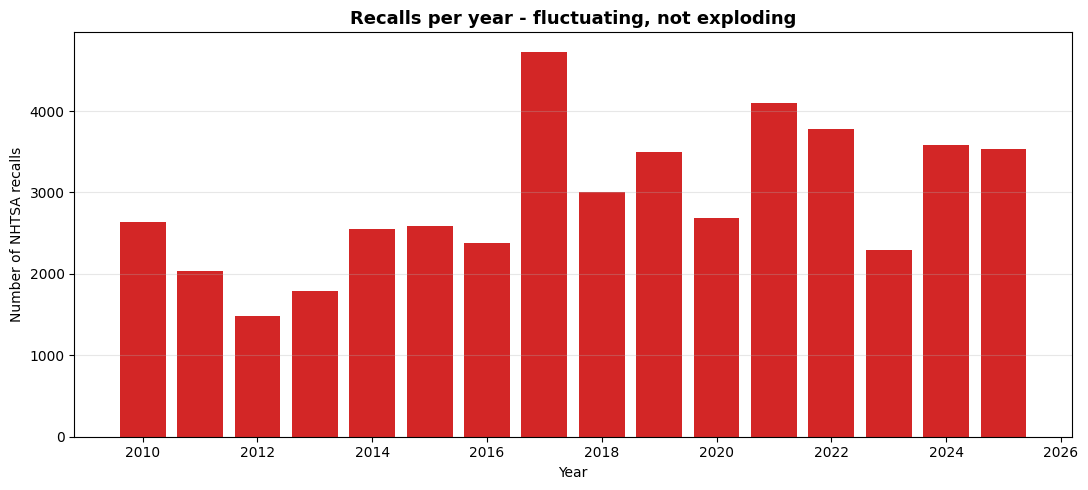

In [63]:
recalls_per_year = df.groupby("recall_year").size()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(recalls_per_year.index, recalls_per_year.values, color="#c00", alpha=0.85)
ax.set_title("Recalls per year - fluctuating, not exploding", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of NHTSA recalls")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

Daniel panicked. "See! The number is EXPLODING! Modern cars are WORSE than before!"

Jack shook his head. "Look closer. It actually oscillates between 1500 and 4700 per year - not a monotonic climb. And much of the volume traces back to a handful of massive events. Look at how many vehicles are actually touched each year."

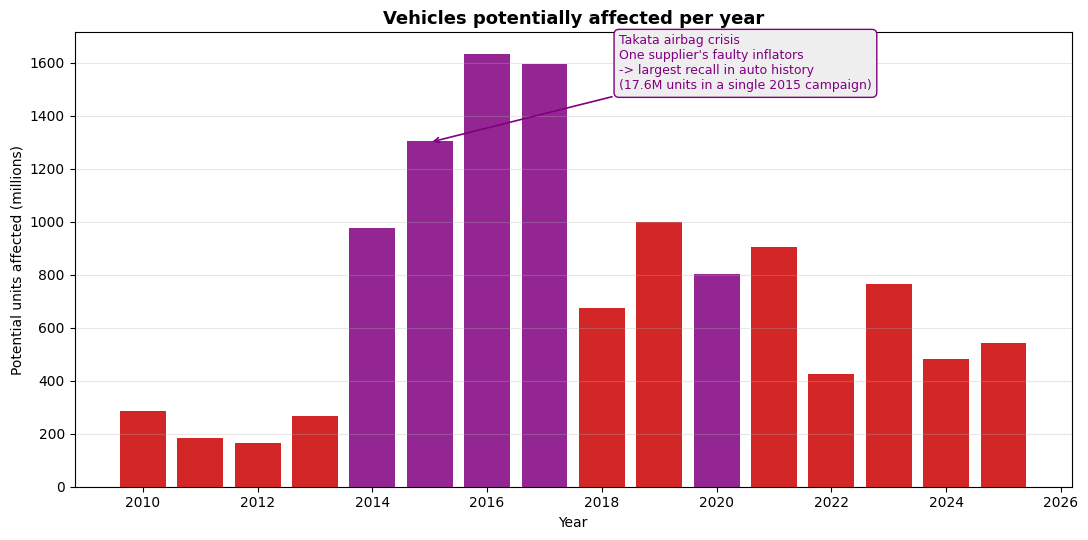

In [70]:
units_per_year = df.groupby("recall_year")["potential_units_affected"].sum() / 1e6

takata_years = {2014, 2015, 2016, 2017, 2020}

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(units_per_year.index, units_per_year.values,
              color=["purple" if y in takata_years else "#c00" for y in units_per_year.index],
              alpha=0.85)

ax.annotate("Takata airbag crisis\nOne supplier's faulty inflators\n-> largest recall in auto history\n(17.6M units in a single 2015 campaign)",
            xy=(2015, 1300), xytext=(2018.3, 1500),
            fontsize=9, color="purple",
            arrowprops=dict(arrowstyle="->", color="purple", lw=1.2),
            bbox=dict(boxstyle="round,pad=0.4", fc="#eee", ec="purple"))

ax.set_title("Vehicles potentially affected per year",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Potential units affected (millions)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

"See those purple bars, Daniel? Those are years dominated by the Takata airbag crisis. One Japanese supplier's faulty propellant caused the largest automotive recall in history - over 17 million vehicles in a single 2015 campaign, across **every brand** that used Takata inflators. It killed people. But the system tracked the root cause, transparented it, and forced fixes across the whole industry. That's the recall ecosystem catching a systemic problem one supplier deep - not a sign that modern cars are worse."

"And here's another angle. Look at the *types* of defects over time. The mix tells you what the industry is actually struggling with."

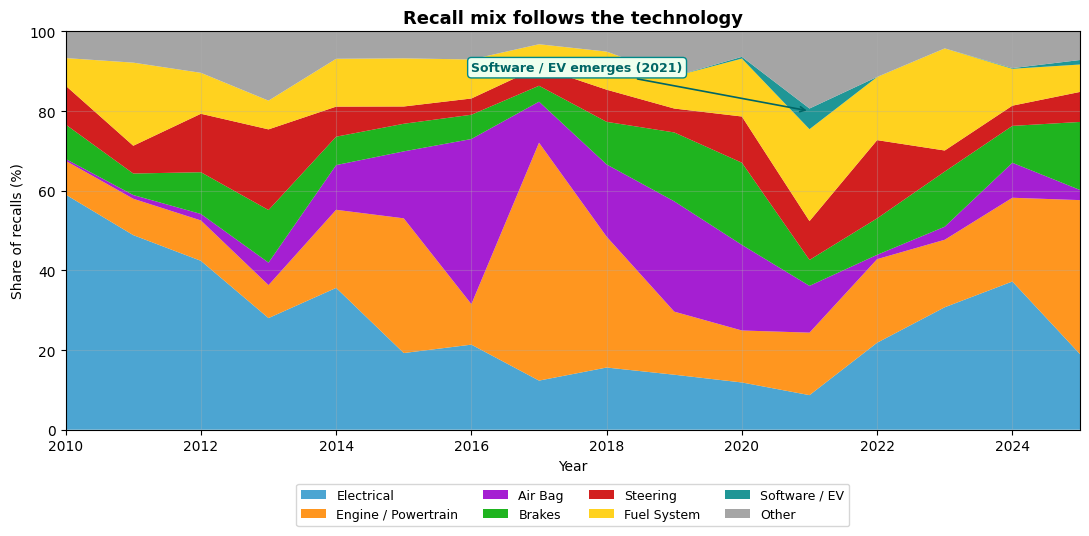

In [ ]:
component_mix = pd.crosstab(df["recall_year"], df["component_category"], normalize="index") * 100

focus = ["Electrical", "Engine / Powertrain", "Air Bag", "Brakes",
         "Steering", "Fuel System", "Software / EV"]
mix = component_mix[focus].copy()
mix["Other"] = 100 - mix.sum(axis=1)

colors = ["#39c", "#f80", "#90c", "#0a0", "#c00", "#fc0", "#088", "#999"]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.stackplot(mix.index, mix.T.values, labels=mix.columns, colors=colors, alpha=0.88)

sw_share = mix["Software / EV"]
peak_year = sw_share.idxmax()
ax.annotate("Software / EV emerges (2021)",
            xy=(peak_year, 80), xytext=(peak_year - 5, 90),
            fontsize=9, color="#066", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#066", lw=1.2),
            bbox=dict(boxstyle="round,pad=0.3", fc="#efe", ec="#088"))

ax.set_title("Recall mix follows the technology",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Share of recalls (%)")
ax.set_ylim(0, 100)
ax.set_xlim(mix.index.min(), mix.index.max())
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

Jack summed up: "Here's the real story, Daniel.

- Recalls don't actually explode - they oscillate, with peaks tied to specific systemic events (Takata).
- A single supplier's failure can dominate an entire decade of recall volume - and the system catches it, traces it back to the root, forces fixes across **every brand** that used the part.
- Defect types shift with the technology: electrical wiring used to dominate, now powertrain complexity is rising, and Software/EV is emerging as its own category in the 2020s.

If you read the bar chart alone, you panic. If you read the *composition* of those recalls, you see a system that tracks systemic root causes across the whole industry. Modern cars aren't safer just because of ABS and airbags - they're safer because when a part fails, even one made by a third-party supplier in Japan, the NHTSA can trace it, publish it, and force every affected brand to fix it."

Daniel was starting to understand. But he looked at the Waymo poster one last time: "And what about the autonomous ones? Are there recalls for those too?"

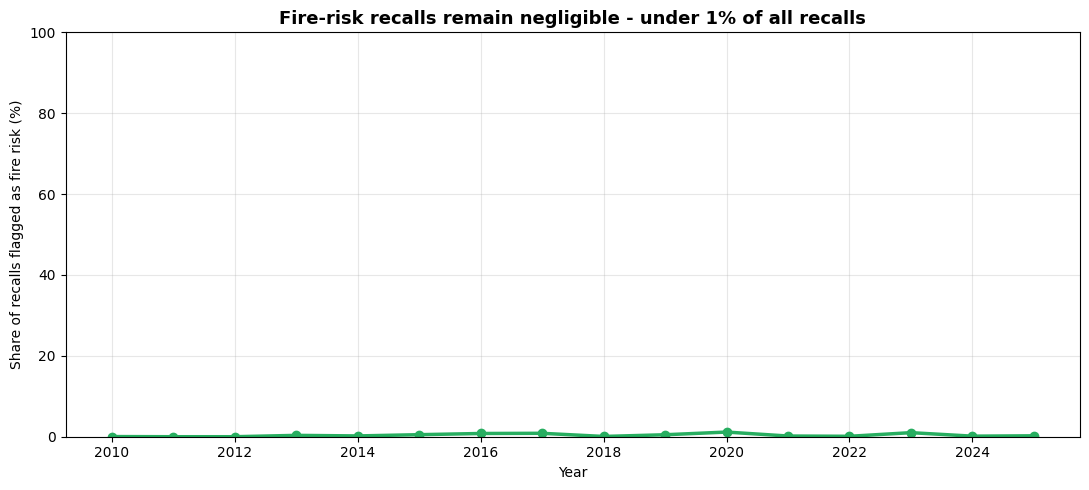

In [73]:
fire_share = df.groupby("recall_year")["fire_risk_flag"].mean() * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(fire_share.index, fire_share.values,
        color="#27ae60", linewidth=2.5, marker="o")
ax.set_title("Fire-risk recalls remain negligible - under 1% of all recalls", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Share of recalls flagged as fire risk (%)")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()

"Look at the fire-risk data," said Jack. "Across 15 years of recalls, including the rise of electric vehicles, lithium batteries, and high-voltage packs, fire-related recalls represent less than 1% of all recalls. Even with new battery technologies, the share stays negligible. That's the system working: catching potential fire risks at the design stage, before they spread to the road."

Daniel smiled for the first time since the airport. "So even the Waymo I rode, an autonomous EV, is statistically safer than the car I crashed in my twenties."

"Exactly," said Jack. "Modern vehicles aren't just safer in theory. They're safer in the data."

# Conclusion

Three things to take away from this story:

1. Cars really are safer today. The fatality rate per 10,000 vehicles dropped from ~30 in the 1920s to about 1 today. That's not an accident.

2. It's not just the features (ABS, airbag, ESC, AEB) that saved lives. Regulation, recall transparency, public quality reports, specialized press. If we credit the features alone without naming the system that makes them mandatory and verifiable, we are "doing the right thing for the wrong reason" (cf. course material).

3. Autonomous cars won't escape this system. Waymo, Tesla FSD, and their successors will have to go through the same machinery of public recalls, audits, and transparency.